### Завдання 1. Кластеризація клієнтів інтернет-магазину
- Мета: знайти сегменти клієнтів для персоналізованих пропозицій.
- Дані:
    - CustomerID — унікальний ідентифікатор
    - Purchases — кількість покупок за останній рік
    - AvgPurchaseValue — середня сума покупки
    - RecencyDays — кількість днів від останньої покупки
- Завдання:
1. Масштабуйте дані.
2. Використайте K-means для пошуку оптимальної кількості кластерів (метод ліктя).
3. Проаналізуйте середні показники кожного кластера і дайте назви сегментам (наприклад, “Активні”, “Сплячі”, “Преміум”).
4. Побудуйте scatter plot Purchases vs AvgPurchaseValue з кольорами кластерів.
- Підказки:
    - Використати StandardScaler перед K-means.
    - Візуалізація допомагає зрозуміти поведінку клієнтів.

📊 Перші рядки даних:
   CustomerID  Purchases  AvgPurchaseValue  RecencyDays
0           1         25                45           10
1           2          3               120          200
2           3         12                60           30
3           4          7                80          100
4           5         30                40            5


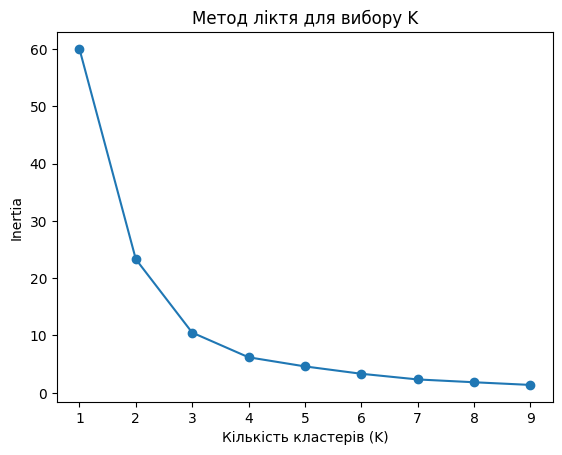


🔹 Кількість клієнтів у кожному кластері:
Cluster
0    9
1    8
2    3
Name: count, dtype: int64

🔹 Середні показники по кожному кластеру:
         Purchases  AvgPurchaseValue  RecencyDays
Cluster                                          
0              9.2              80.0         63.3
1             28.1              45.4         16.6
2              3.0             126.7        200.0


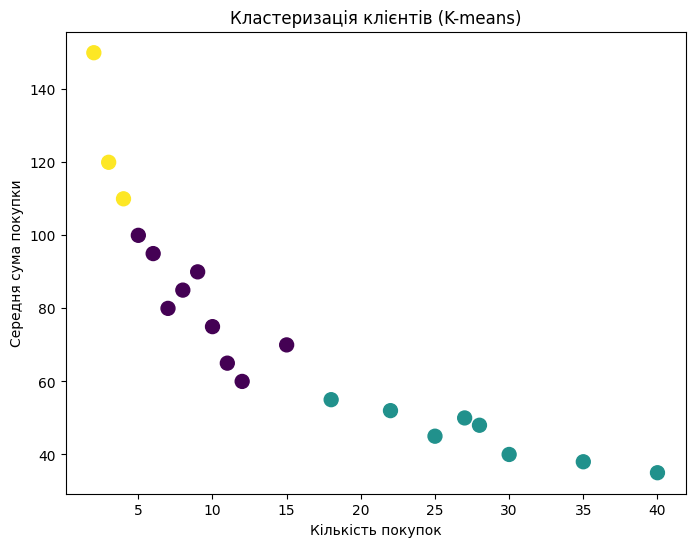


📈 Silhouette Score: 0.494


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 0. Проведемо генерацію демо-даних 
data = {
    'CustomerID': range(1, 21),
    'Purchases': [25, 3, 12, 7, 30, 18, 4, 40, 9, 15, 27, 2, 10, 35, 6, 22, 8, 11, 5, 28],
    'AvgPurchaseValue': [45, 120, 60, 80, 40, 55, 110, 35, 90, 70, 50, 150, 75, 38, 95, 52, 85, 65, 100, 48],
    'RecencyDays': [10, 200, 30, 100, 5, 20, 150, 2, 80, 60, 12, 250, 40, 8, 90, 70, 15, 35, 120, 6]
}
df = pd.DataFrame(data)

print("📊 Перші рядки даних:")
print(df.head())

# 1. Масштабування даних
features = ['Purchases', 'AvgPurchaseValue', 'RecencyDays']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# 2. Використаємо K-means та методу ліктя
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 додамо для стабільності
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title('Метод ліктя для вибору K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('Inertia')
plt.show()

# 3. Проведемо навчання моделі з K=3 (оптимальне з "ліктя")
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n🔹 Кількість клієнтів у кожному кластері:")
print(df['Cluster'].value_counts())

print("\n🔹 Середні показники по кожному кластеру:")
cluster_means = df.groupby('Cluster')[features].mean().round(1)
print(cluster_means)

# 4. Побудуємо scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Purchases'], df['AvgPurchaseValue'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel('Кількість покупок')
plt.ylabel('Середня сума покупки')
plt.title('Кластеризація клієнтів (K-means)')
plt.show()

# Додатково: Оцінемо якість 
score = silhouette_score(X_scaled, df['Cluster'])
print(f"\n📈 Silhouette Score: {score:.3f}")

Демо-дані згенеровано (150 клієнтів, 3 приховані групи):
   Purchases  AvgPurchaseValue  RecencyDays  CustomerID
0   5.682304         21.936421   300.306992          74
1  45.459880        207.232721    20.714114          19
2  10.972499         50.976761    51.792972         119
3   4.470686         26.423481   302.094063          79
4   5.026004         30.321400   305.971791          77

Дані масштабовано.
Графік 'ліктя' збережено у 'elbow_plot.png'

Кластеризацію на K=3 завершено.

Середні показники для кожного кластера (в оригінальних одиницях):
   Purchases  AvgPurchaseValue  RecencyDays
0  48.872630        200.355617    14.803562
1  10.096544         51.814989    39.512558
2   5.167793         30.754847   299.364695
Графік кластерів збережено у 'customer_clusters.png'


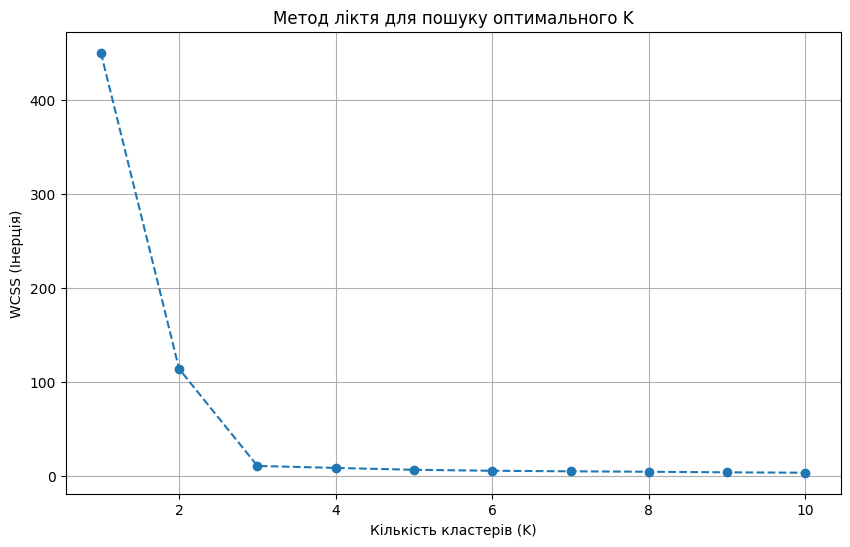

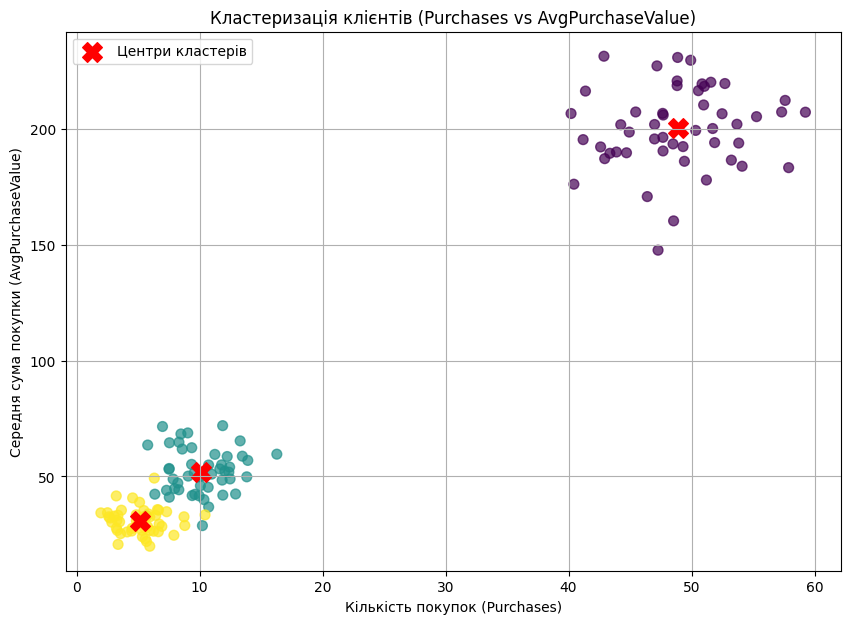

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- 0. Проведемо генерацію Демо-даних  ---
# Створимо 3 чіткі групи для прикладу
np.random.seed(42)
# Група 0: "Активні/Преміум" (часто купують, дорого, недавно)
data_0 = pd.DataFrame({
    'Purchases': np.random.normal(50, 5, 50),
    'AvgPurchaseValue': np.random.normal(200, 20, 50),
    'RecencyDays': np.random.normal(15, 5, 50)
})
# Група 1: "Сплячі" (рідко купують, дешево, давно)
data_1 = pd.DataFrame({
    'Purchases': np.random.normal(5, 2, 50),
    'AvgPurchaseValue': np.random.normal(30, 5, 50),
    'RecencyDays': np.random.normal(300, 30, 50)
})
# Група 2: "Група ризику" (купували недавно, але мало і дешево)
data_2 = pd.DataFrame({
    'Purchases': np.random.normal(10, 3, 50),
    'AvgPurchaseValue': np.random.normal(50, 10, 50),
    'RecencyDays': np.random.normal(40, 10, 50)
})

data = pd.concat([data_0, data_1, data_2], ignore_index=True)
# Додамо CustomerID
data['CustomerID'] = range(1, len(data) + 1)
# Перемішаємо дані
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print("Демо-дані згенеровано (150 клієнтів, 3 приховані групи):")
print(data.head())

# --- 1. Проведемо масштабування даних ---
# Вибираємо ознаки для кластеризації (без CustomerID)
features = ['Purchases', 'AvgPurchaseValue', 'RecencyDays']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nДані масштабовано.")

# --- 2. Проведемо метод ліктя (Пошук оптимального K) ---
# WCSS - Within-Cluster Sum of Squares (внутрішньокластерна сума квадратів)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ це і є WCSS

# Проведемо візуалізацію "ліктя"
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Метод ліктя для пошуку оптимального K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('WCSS (Інерція)')
plt.grid(True)
plt.savefig('elbow_plot.png')
print("Графік 'ліктя' збережено у 'elbow_plot.png'")

# --- 3. Проведемо кластеризацію та Аналіз (K=3) ---
# Згідно з графіком ліктя (для цих демо-даних), "лікоть" знаходиться на K=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nКластеризацію на K={k_optimal} завершено.")

# Аналізуємо центри кластерів
# kmeans.cluster_centers_ - це масштабовані центри
centers_scaled = kmeans.cluster_centers_

# Повертаємо центри до оригінальних значень для інтерпретації
centers_original = scaler.inverse_transform(centers_scaled)

# Створюємо DataFrame для легкого аналізу
centers_df = pd.DataFrame(centers_original, columns=features)
print("\nСередні показники для кожного кластера (в оригінальних одиницях):")
print(centers_df)

# --- 4. Проведемо візуалізацію кластерів ---
plt.figure(figsize=(10, 7))
plt.scatter(
    data['Purchases'], 
    data['AvgPurchaseValue'], 
    c=data['Cluster'], 
    cmap='viridis',  # Кольорова схема
    alpha=0.7, 
    s=50
)
# Малюємо центри кластерів (оригінальні значення)
plt.scatter(
    centers_df['Purchases'], 
    centers_df['AvgPurchaseValue'], 
    c='red', 
    marker='X', 
    s=200, 
    label='Центри кластерів'
)
plt.title('Кластеризація клієнтів (Purchases vs AvgPurchaseValue)')
plt.xlabel('Кількість покупок (Purchases)')
plt.ylabel('Середня сума покупки (AvgPurchaseValue)')
plt.legend()
plt.grid(True)
plt.savefig('customer_clusters.png')
print("Графік кластерів збережено у 'customer_clusters.png'")

### Завдання 2. Виявлення аномальних транзакцій у банку
- Мета: знайти підозрілі транзакції, які можуть бути шахрайськими.
- Дані:
    - TransactionID — унікальний код транзакції
    - Amount — сума транзакції
    - TimeSinceLast — час у днях від попередньої транзакції клієнта
- Завдання:
1. Масштабуйте числові ознаки.
2. Використайте DBSCAN для виявлення аномалій (шумові точки отримають мітку -1).
3. Виведіть транзакції, які вважаються аномальними.
4. Побудуйте scatter plot Amount vs TimeSinceLast, позначивши аномалії окремим кольором.
- Підказки:
- Почніть з eps=0.5 і min_samples=5 і підбирайте параметри експериментально.
- Шуми у DBSCAN часто означають аномальні або рідкісні події.

📊 Демо-дані згенеровано (105 транзакцій, 5 аномалій):
      Amount  TimeSinceLast  TransactionID
0  43.982934       0.224668             31
1  63.562400       1.206390             66
2  58.125258       1.481688             65
3  56.116763       1.116127             54
4  42.801558       1.390911             46

Дані масштабовано.
Кластеризацію DBSCAN завершено.

🔹 Аномальні транзакції (Мітка -1):
     Amount  TimeSinceLast  TransactionID  Cluster_DB
6     480.0            9.0            105          -1
32    520.0           15.0            104          -1
70    500.0           10.0            101          -1
72    450.0           12.0            102          -1
104   600.0            8.0            103          -1

Графік аномалій збережено у 'dbscan_anomalies.png'


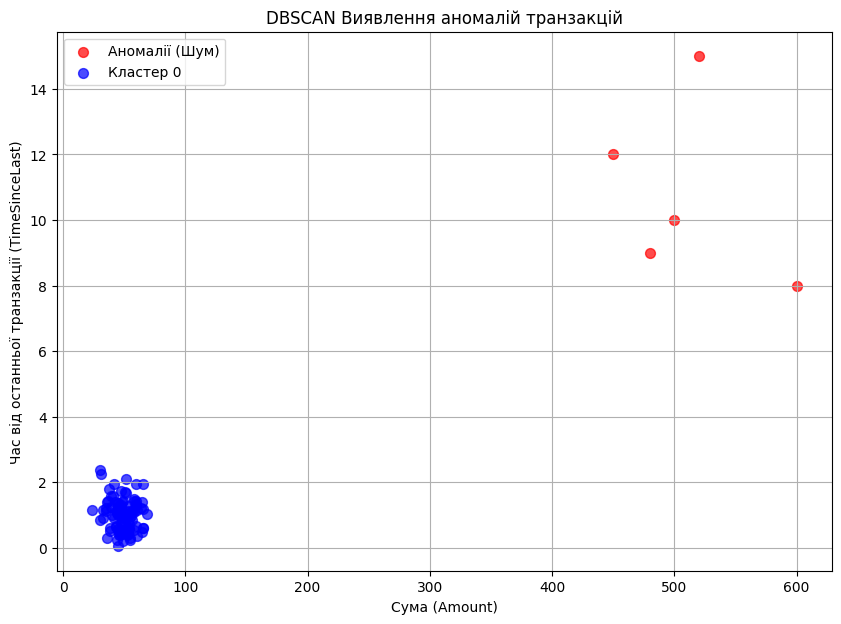

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# --- 0. Проведемо генерацію Демо-даних  ---
np.random.seed(42)
# 100 "звичайних" транзакцій (невеликі суми, невеликий час)
normal_transactions = pd.DataFrame({
    'Amount': np.random.normal(50, 10, 100),
    'TimeSinceLast': np.random.normal(1, 0.5, 100)
})
# 5 "аномальних" транзакцій (великі суми, великий час)
anomalies = pd.DataFrame({
    'Amount': [500, 450, 600, 520, 480],
    'TimeSinceLast': [10, 12, 8, 15, 9]
})

data = pd.concat([normal_transactions, anomalies], ignore_index=True)
data['TransactionID'] = range(1, len(data) + 1)
# Перемішаємо дані
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("📊 Демо-дані згенеровано (105 транзакцій, 5 аномалій):")
print(data.head())

# --- 1. Проведемо масштабування числових ознак ---
features = ['Amount', 'TimeSinceLast']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nДані масштабовано.")

# --- 2. Проведемо використання DBSCAN ---
# Починаємо з eps=0.5 і min_samples=5 (як у підказці)
# Ці параметри добре працюють для згенерованих даних
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['Cluster_DB'] = dbscan.fit_predict(X_scaled)

print("Кластеризацію DBSCAN завершено.")

# --- 3. Проведемо введення аномальних транзакцій ---
# Аномалії - це точки з міткою -1
anomalous_transactions = data[data['Cluster_DB'] == -1]

print("\n🔹 Аномальні транзакції (Мітка -1):")
if anomalous_transactions.empty:
    print("Аномалій не знайдено з поточними параметрами.")
else:
    print(anomalous_transactions)

# --- 4. Побудуємо scatter plot ---
plt.figure(figsize=(10, 7))

# Визначимо кольори для кластерів
# -1 (аномалії) будуть червоними, 0 (звичайні) - синіми, і т.д.
colors = {-1: 'red', 0: 'blue', 1: 'green', 2: 'purple'}
labels = {-1: 'Аномалії (Шум)', 0: 'Кластер 0', 1: 'Кластер 1', 2: 'Кластер 2'}

for cluster_id in np.unique(data['Cluster_DB']):
    subset = data[data['Cluster_DB'] == cluster_id]
    plt.scatter(
        subset['Amount'], 
        subset['TimeSinceLast'], 
        c=colors.get(cluster_id, 'black'),  # .get() для безпеки, якщо кластерів більше
        label=labels.get(cluster_id, f'Кластер {cluster_id}'),
        s=50,
        alpha=0.7
    )

plt.title('DBSCAN Виявлення аномалій транзакцій')
plt.xlabel('Сума (Amount)')
plt.ylabel('Час від останньої транзакції (TimeSinceLast)')
plt.legend()
plt.grid(True)
plt.savefig('dbscan_anomalies.png')
print("\nГрафік аномалій збережено у 'dbscan_anomalies.png'")

### Завдання 3. Кластеризація гравців онлайн-ігри
- Мета: сегментація гравців для таргетованих пропозицій та нагород.
- Дані:
    - PlayerID — унікальний ідентифікатор
    - HoursPlayed — кількість годин, проведених в грі
    - LevelReached — досягнутий рівень
    - InGamePurchases — витрати у грі
- Завдання:
1. Масштабуйте дані.
2. Використайте K-means, підберіть оптимальне K (метод ліктя).
3. Визначте типи гравців: “Casual”, “Hardcore”, “Big Spender”.
4. Побудуйте scatter plot HoursPlayed vs InGamePurchases, позначивши кластери кольорами.
- Підказки:
    - Масштабування важливе, бо HoursPlayed і InGamePurchases мають різні масштаби.
    - K-means добре працює, якщо кластери приблизно сферичні.

📊 Демо-дані згенеровано (150 гравців, 3 приховані групи):
   HoursPlayed  LevelReached  InGamePurchases  PlayerID
0    63.411520     31.936421       200.255827        74
1   172.759278     81.808180        20.714114        19
2    21.620832     10.293028         7.358594       119
3    57.353432     36.423481       201.745052        79
4    60.130019     40.321400       204.976492        77

Дані масштабовано.
Графік 'ліктя' збережено у 'elbow_plot_players.png'

Кластеризацію на K=3 завершено.

🔹 Середні показники по кожному кластеру (в оригінальних одиницях):
         HoursPlayed  LevelReached  InGamePurchases
Cluster                                            
0              193.2          80.1             14.8
1               20.2          10.5              4.9
2               60.8          40.8            199.5
Графік кластерів збережено у 'player_clusters.png'

📈 Silhouette Score: 0.861


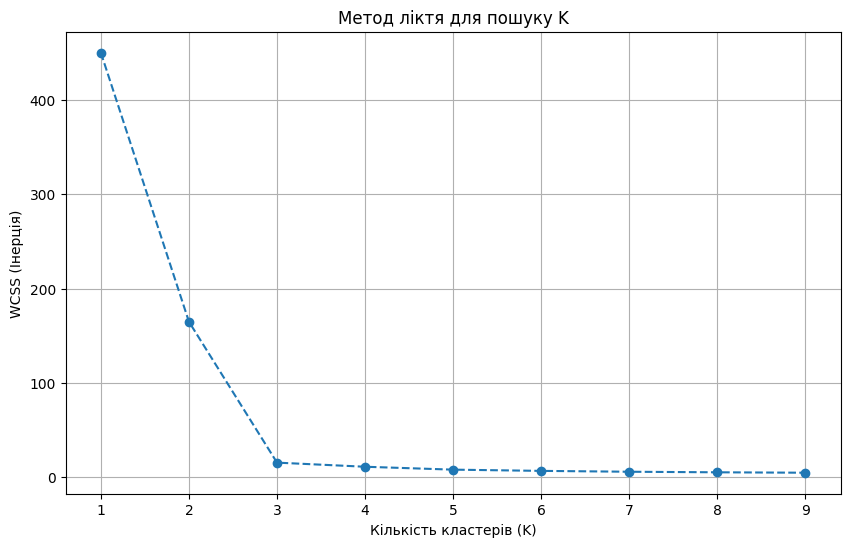

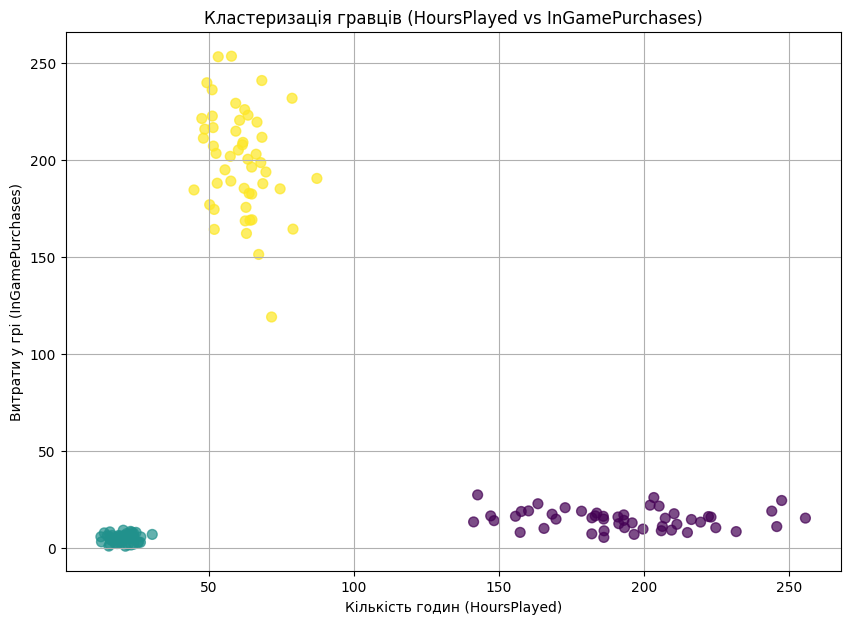

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 0. Проведемо генерацію Демо-даних ---
np.random.seed(42)

# Група 0: "Hardcore" (Багато годин, високий рівень, мало витрат)
data_0 = pd.DataFrame({
    'HoursPlayed': np.random.normal(200, 30, 50),
    'LevelReached': np.random.normal(80, 5, 50),
    'InGamePurchases': np.random.normal(15, 5, 50)
})
# Група 1: "Big Spenders" (Середньо годин, середній рівень, багато витрат)
data_1 = pd.DataFrame({
    'HoursPlayed': np.random.normal(60, 10, 50),
    'LevelReached': np.random.normal(40, 5, 50),
    'InGamePurchases': np.random.normal(200, 25, 50)
})
# Група 2: "Casual" (Мало годин, низький рівень, мало витрат)
data_2 = pd.DataFrame({
    'HoursPlayed': np.random.normal(20, 5, 50),
    'LevelReached': np.random.normal(10, 3, 50),
    'InGamePurchases': np.random.normal(5, 2, 50)
})

data = pd.concat([data_0, data_1, data_2], ignore_index=True)
data['PlayerID'] = range(1, len(data) + 1)
# Перемішаємо дані
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("📊 Демо-дані згенеровано (150 гравців, 3 приховані групи):")
print(data.head())

# --- 1. Проведемо масштабування даних ---
features = ['HoursPlayed', 'LevelReached', 'InGamePurchases']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nДані масштабовано.")

# --- 2. Проведемо метод ліктя (Пошук оптимального K) ---
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Візуалізація "ліктя"
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Метод ліктя для пошуку K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('WCSS (Інерція)')
plt.grid(True)
plt.savefig('elbow_plot_players.png')
print("Графік 'ліктя' збережено у 'elbow_plot_players.png'")

# --- 3. Проведемо кластеризацію та Аналіз (K=3) ---
# Завдання вимагає 3 типи, і "лікоть" на демо-даних також вказує на K=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nКластеризацію на K={k_optimal} завершено.")

# Аналізуємо середні показники
cluster_means = data.groupby('Cluster')[features].mean().round(1)
print("\n🔹 Середні показники по кожному кластеру (в оригінальних одиницях):")
print(cluster_means)

# --- 4. Проведемо візуалізацію кластерів ---
plt.figure(figsize=(10, 7))
plt.scatter(
    data['HoursPlayed'], 
    data['InGamePurchases'], 
    c=data['Cluster'], 
    cmap='viridis',  # Кольорова схема
    alpha=0.7, 
    s=50
)
plt.title('Кластеризація гравців (HoursPlayed vs InGamePurchases)')
plt.xlabel('Кількість годин (HoursPlayed)')
plt.ylabel('Витрати у грі (InGamePurchases)')
plt.grid(True)
plt.savefig('player_clusters.png')
print("Графік кластерів збережено у 'player_clusters.png'")

# Оцінка якості (додатково)
score = silhouette_score(X_scaled, data['Cluster'])
print(f"\n📈 Silhouette Score: {score:.3f}")

### Завдання 4. Кластеризація міст за демографічними показниками
- Мета: виділити групи міст за соціально-економічними характеристиками.
- Дані:
    - City — назва міста
    - Population — населення
    - MedianIncome — середній дохід
    - UnemploymentRate — рівень безробіття
- Завдання:
1. Масштабуйте дані.
2. Використайте K-means або DBSCAN для групування міст.
3. Проаналізуйте середні значення ознак у кожному кластері.
4. Побудуйте scatter plot Population vs MedianIncome з кольорами кластерів.
Підказки:
    - DBSCAN може виділити міста, які суттєво відрізняються від інших.
    - K-means дозволяє отримати більш збалансовані групи.

📊 Демо-дані згенеровано (30 міст, 3 приховані групи):
      Population  MedianIncome  UnemploymentRate          City
0  290141.315916  24401.985299          6.230126    Regional_7
1   37791.563500  13920.233687         12.931280  Small_Town_5
2  202151.735037  28129.287312          5.637211    Regional_3
3   30403.298761  16585.683339         11.690788  Small_Town_7
4  929578.842110  37275.927773          3.199681   Metro_Hub_8

Дані масштабовано.
Графік 'ліктя' збережено у 'elbow_plot_cities.png'

Кластеризацію на K=3 завершено.

🔹 Середні показники по кожному кластеру (в оригінальних одиницях):
         Population  MedianIncome  UnemploymentRate
Cluster                                            
0           46898.9       14620.8              12.2
1         1067209.2       37628.0               3.4
2          249397.7       24904.5               6.1
Графік кластерів збережено у 'city_clusters.png'

📈 Silhouette Score: 0.817


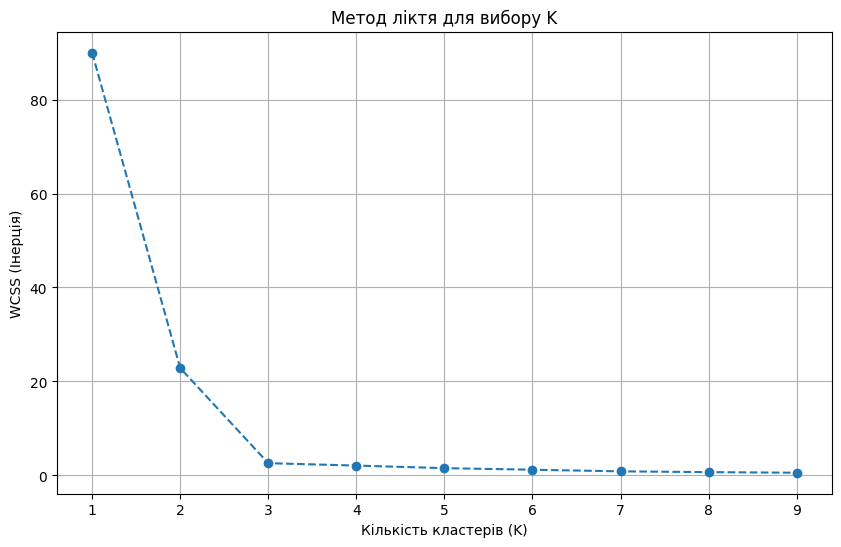

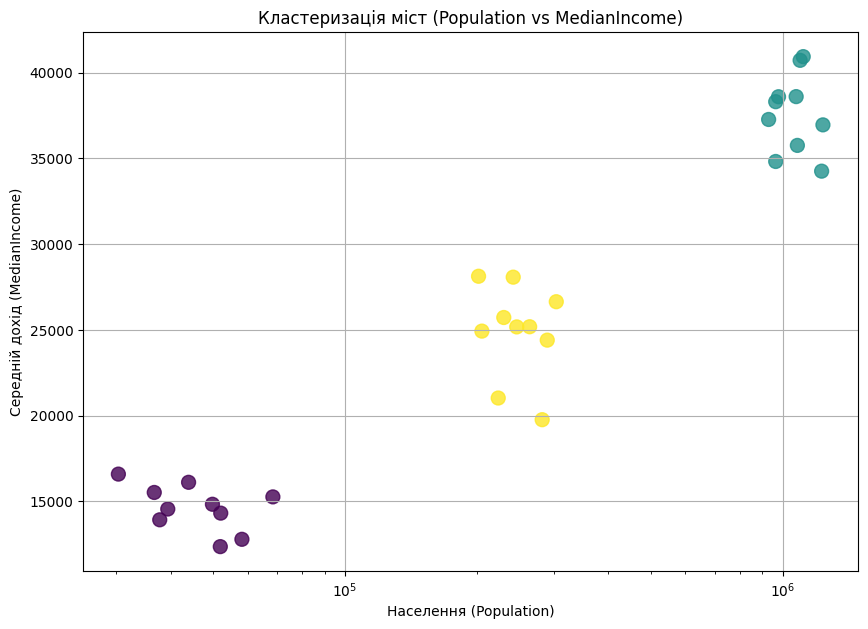

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 0. Проведемо генерацію Демо-даних  ---
np.random.seed(42)

# Група 0: "Великі Економічні Центри" (Високе населення, високий дохід, низьке безробіття)
data_0 = pd.DataFrame({
    'Population': np.random.normal(1_000_000, 150_000, 10),
    'MedianIncome': np.random.normal(40000, 3000, 10),
    'UnemploymentRate': np.random.normal(3.5, 0.5, 10)
})
data_0['City'] = [f'Metro_Hub_{i}' for i in range(10)]

# Група 1: "Малі Депресивні Міста" (Низьке населення, низький дохід, високе безробіття)
data_1 = pd.DataFrame({
    'Population': np.random.normal(50_000, 10_000, 10),
    'MedianIncome': np.random.normal(15000, 1500, 10),
    'UnemploymentRate': np.random.normal(12.0, 1.0, 10)
})
data_1['City'] = [f'Small_Town_{i}' for i in range(10)]

# Група 2: "Середні Регіональні Міста" (Середні показники)
data_2 = pd.DataFrame({
    'Population': np.random.normal(250_000, 40_000, 10),
    'MedianIncome': np.random.normal(25000, 2000, 10),
    'UnemploymentRate': np.random.normal(6.0, 0.7, 10)
})
data_2['City'] = [f'Regional_{i}' for i in range(10)]

data = pd.concat([data_0, data_1, data_2], ignore_index=True)
# Перемішаємо дані
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("📊 Демо-дані згенеровано (30 міст, 3 приховані групи):")
print(data.head())

# --- 1. Проведемо масштабування даних ---
features = ['Population', 'MedianIncome', 'UnemploymentRate']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nДані масштабовано.")

# --- 2. Проведемо метод ліктя (Пошук оптимального K) ---
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Проведемо візуалізацію "ліктя"
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Метод ліктя для вибору K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('WCSS (Інерція)')
plt.grid(True)
plt.savefig('elbow_plot_cities.png')
print("Графік 'ліктя' збережено у 'elbow_plot_cities.png'")

# --- 2. Проведемо навчання моделі K-means (K=3) ---
k_optimal = 3 # "Лікоть" на демо-даних чітко вказує на 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nКластеризацію на K={k_optimal} завершено.")

# --- 3. Проведемо аналіз середніх значень ознак ---
cluster_means = data.groupby('Cluster')[features].mean().round(1)
print("\n🔹 Середні показники по кожному кластеру (в оригінальних одиницях):")
print(cluster_means)

# --- 4. Побудуємо scatter plot ---
plt.figure(figsize=(10, 7))
plt.scatter(
    data['Population'], 
    data['MedianIncome'], 
    c=data['Cluster'], 
    cmap='viridis',
    alpha=0.8, 
    s=100
)
plt.title('Кластеризація міст (Population vs MedianIncome)')
plt.xlabel('Населення (Population)')
plt.ylabel('Середній дохід (MedianIncome)')
# Використовуємо логарифмічну шкалу для населення, щоб краще бачити кластери
plt.xscale('log') 
plt.grid(True)
plt.savefig('city_clusters.png')
print("Графік кластерів збережено у 'city_clusters.png'")

# Проведемо оцінку якості (додатково)
score = silhouette_score(X_scaled, data['Cluster'])
print(f"\n📈 Silhouette Score: {score:.3f}")

### Завдання 5. Виявлення сегментів продуктів
- Мета: розділити товари на категорії за популярністю та ціною.
- Дані:
    - ProductID — унікальний код продукту
    - SalesVolume — кількість продажів
    - Price — ціна продукту
- Завдання:
1. Масштабуйте дані.
2. Використайте DBSCAN для пошуку груп продуктів з подібною популярністю і ціною.
3. Визначте, які продукти є “нішею” або “популярні хіти”.
4. Побудуйте scatter plot Price vs SalesVolume, позначивши кластери і шуми.
- Підказки:
    - eps потрібно підбирати залежно від масштабу даних.
    - Товари з міткою -1 у DBSCAN можуть бути “унікальними” або дорогими нішевими продуктами.

📊 Демо-дані згенеровано (185 продуктів, 5 аномалій):
   SalesVolume      Price  ProductID
0   457.630889  16.503866         20
1   496.530552  11.785034         43
2   119.003667  45.872514        157
3   117.033485  47.534995        112
4   126.481814  53.120599        149

Дані масштабовано.
Кластеризацію DBSCAN завершено.

🔹 Унікальні мітки кластерів (DBSCAN):
[-1  0  1]

🔹 'Нішеві' продукти (Аномалії, Мітка -1):
     SalesVolume  Price  ProductID  Cluster
71           5.0  500.0        181       -1
106         12.0  700.0        184       -1
119          8.0  550.0        183       -1
154         10.0  600.0        182       -1
177         15.0  650.0        185       -1

🔹 'Популярні Хіти' (Кластер 0):
   SalesVolume      Price  ProductID  Cluster
0   457.630889  16.503866         20        0
1   496.530552  11.785034         43        0
5   483.131374  15.603095         16        0
6   483.668518  16.173714         25        0
7   510.849081  14.509224         69        0

Графік

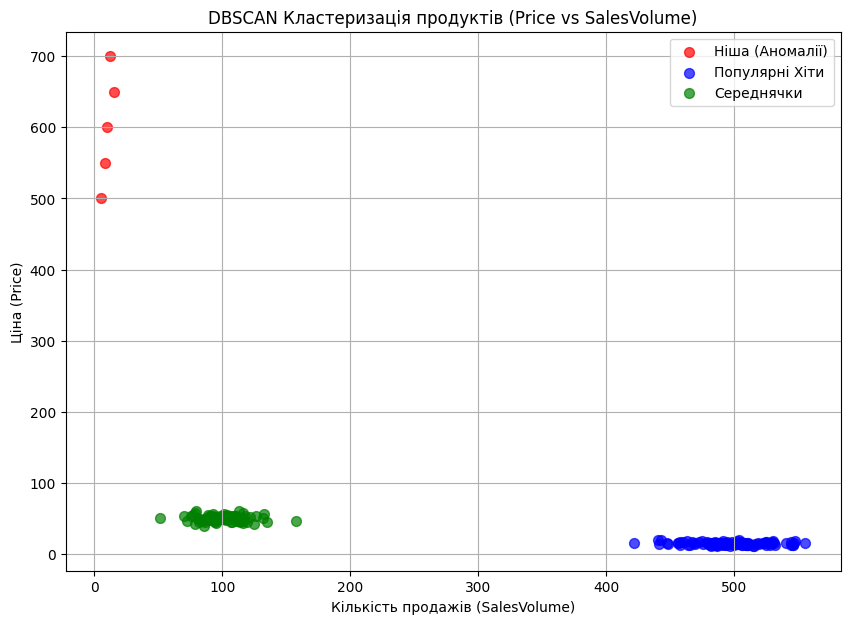

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# --- 0. Проведемо генерацію Демо-даних  ---
np.random.seed(42)

# Група 0: "Популярні Хіти" (Високі продажі, низька ціна) - щільний
data_0 = pd.DataFrame({
    'SalesVolume': np.random.normal(500, 30, 100),
    'Price': np.random.normal(15, 2, 100)
})
# Група 1: "Середнячки" (Середні продажі, середня ціна) - щільний
data_1 = pd.DataFrame({
    'SalesVolume': np.random.normal(100, 15, 80),
    'Price': np.random.normal(50, 5, 80)
})
# Група -1: "Ніша/Люкс" (Низькі продажі, висока ціна) - розріджені
data_noise = pd.DataFrame({
    'SalesVolume': [5, 10, 8, 12, 15],
    'Price': [500, 600, 550, 700, 650]
})

data = pd.concat([data_0, data_1, data_noise], ignore_index=True)
data['ProductID'] = range(1, len(data) + 1)
# Перемішаємо дані
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("📊 Демо-дані згенеровано (185 продуктів, 5 аномалій):")
print(data.head())

# --- 1.Проведемо масштабування даних ---
features = ['SalesVolume', 'Price']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nДані масштабовано.")

# --- 2. Проведемо використання DBSCAN ---
# Використовуємо параметри з підказки
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['Cluster'] = dbscan.fit_predict(X_scaled)

print("Кластеризацію DBSCAN завершено.")
print("\n🔹 Унікальні мітки кластерів (DBSCAN):")
print(np.unique(data['Cluster'])) # Має показати 0, 1, -1

# --- 3. Проведемо визначення сегментів (Ніша / Хіти) ---
# "Ніша" - це шумові точки (мітка -1)
niche_products = data[data['Cluster'] == -1]
print("\n🔹 'Нішеві' продукти (Аномалії, Мітка -1):")
print(niche_products)

# "Популярні Хіти" - це кластер 0 (на наших демо-даних)
popular_hits = data[data['Cluster'] == 0]
print("\n🔹 'Популярні Хіти' (Кластер 0):")
print(popular_hits.head()) # Покажемо лише перші 5

# --- 4. Побудуємо scatter plot ---
plt.figure(figsize=(10, 7))

# Визначимо кольори для кластерів
colors = {-1: 'red', 0: 'blue', 1: 'green'}
labels = {-1: 'Ніша (Аномалії)', 0: 'Популярні Хіти', 1: 'Середнячки'}

for cluster_id in np.unique(data['Cluster']):
    subset = data[data['Cluster'] == cluster_id]
    plt.scatter(
        subset['SalesVolume'], 
        subset['Price'], 
        c=colors.get(cluster_id),
        label=labels.get(cluster_id),
        s=50,
        alpha=0.7
    )

plt.title('DBSCAN Кластеризація продуктів (Price vs SalesVolume)')
plt.xlabel('Кількість продажів (SalesVolume)')
plt.ylabel('Ціна (Price)')
# Логарифмічна шкала, щоб краще бачити кластери з різними масштабами
# plt.xscale('log') 
# plt.yscale('log')
plt.legend()
plt.grid(True)
plt.savefig('dbscan_products.png')
print("\nГрафік кластерів збережено у 'dbscan_products.png'")